In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from textblob import TextBlob

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RAW_PATH = "../data/raw/customer_clv.csv"
NLP_OUT_DIR = "../data/processed"

In [3]:
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
display(df[["customer_feedback", "nps_score"]].head(5))
print("Missing customer_feedback:", int(df["customer_feedback"].isna().sum()))
print("Missing nps_score:", int(df["nps_score"].isna().sum()))

Shape: (7028, 17)


,customer_feedback,nps_score
0,Customer service was polite but couldn't fix m...,10.0
1,NaN,NaN
2,renewal was automatic and seamless. happy to s...,10.0
3,The Pro plan is worth every penny. ROI was cle...,8.0
4,Super easy to use and the customer support tea...,8.0


Missing customer_feedback: 561
Missing nps_score: 561


In [7]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\.{2,}", ".", text)               # fix: literal dots only
    text = re.sub(r"[^a-z0-9\s\.,!?']", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["feedback_clean"] = df["customer_feedback"].apply(clean_text)

display(df[["customer_feedback", "feedback_clean"]].sample(8, random_state=42))

,customer_feedback,feedback_clean
2476,Switched from a competitor and never looked ba...,switched from a competitor and never looked ba...
6769,Been using this for 84 months and it keeps get...,been using this for 84 months and it keeps get...
4635,Works okay most of the time. Had a couple of o...,works okay most of the time. had a couple of o...
3047,Love this product. It has completely changed h...,love this product. it has completely changed h...
4092,Cancelled my subscription last week. Not what ...,cancelled my subscription last week. not what ...
3218,Support took a while to respond but eventually...,support took a while to respond but eventually...
3768,Exported my data and moving to a competitor. D...,exported my data and moving to a competitor. d...
3463,Renewal was automatic and seamless. Happy to s...,renewal was automatic and seamless. happy to s...


count    7028.000000
mean       10.156375
std         3.399687
min         0.000000
25%        10.000000
50%        11.000000
75%        12.000000
max        14.000000
Name: feedback_word_count, dtype: float64


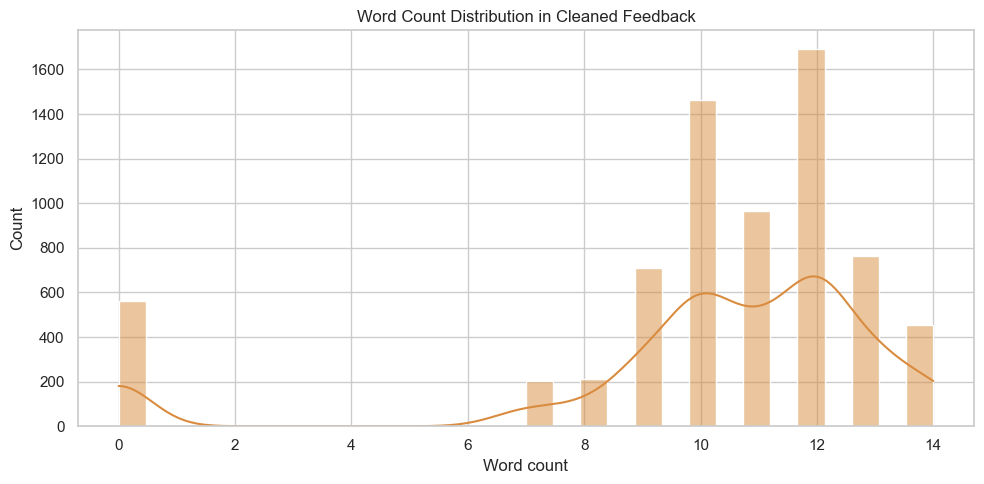

In [8]:
df["feedback_word_count"] = df["feedback_clean"].apply(lambda x: len(x.split()) if x else 0)

print(df["feedback_word_count"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df["feedback_word_count"], bins=30, kde=True, color="#d98c3f")
plt.title("Word Count Distribution in Cleaned Feedback")
plt.xlabel("Word count")
plt.tight_layout()
plt.show()

In [ ]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    stop_words="english",
    sublinear_tf=True,
)

tfidf_matrix = tfidf.fit_transform(df["feedback_clean"].fillna(""))
print("TF-IDF matrix shape:", tfidf_matrix.shape)

tfidf_feature_names = tfidf.get_feature_names_out()
print("Sample TF-IDF terms:", tfidf_feature_names[:20])

TF-IDF matrix shape: (7028, 359)
Sample TF-IDF terms: ['10' '10 months' '10 support' '11' '11 months' '11 support' '12'
 '12 months' '12 support' '13' '13 months' '14' '14 months' '15'
 '15 months' '15 support' '16' '16 months' '17' '17 months']
